

# **What is Logistic Regression?**

Logistic Regression is a **classification** algorithm — it predicts a **category**, not a number.

> Common confusion: despite the name "regression," it is NOT used to predict continuous values like price or temperature. That's what **Linear Regression** does. Logistic Regression is used when the answer is one of a fixed set of classes, e.g.:
> - Email → **Spam** or **Not Spam**
> - Tumor → **Malignant** or **Benign**
> - Customer → **Will Churn** or **Will Not Churn**

### The Core Idea

1. Just like Linear Regression, it first computes a weighted sum of the inputs: `z = w1*x1 + w2*x2 + ... + b`
2. But instead of using `z` directly as the output (which could be any number from -∞ to +∞), it passes `z` through a **Sigmoid function**, which squashes it into a value **between 0 and 1**.
3. That squashed value is interpreted as a **probability**. If the probability is ≥ 0.5, we predict class **1**; otherwise, we predict class **0**.

This notebook builds a Logistic Regression model step-by-step: generating data → training → predicting → evaluating → tuning it to perform better.


In [1]:
# Import essential libraries for data manipulation, numerical computations,
# data visualization, and displaying plots.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


## **The Sigmoid Function**

The Sigmoid function is what makes Logistic Regression work. It takes any real number and maps it to a value between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Very large positive `z` → output close to **1**
- Very large negative `z` → output close to **0**
- `z = 0` → output is exactly **0.5** (this is the decision threshold)

Let's plot it to see the characteristic **S-shaped curve**:


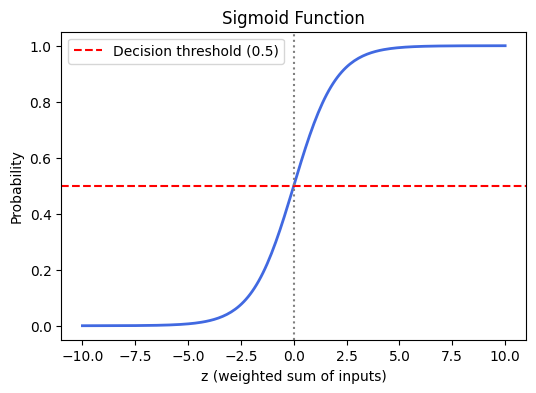

In [2]:
# Plot the Sigmoid function to visualize how it maps any real number to a value between 0 and 1.
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6, 4))
plt.plot(z, sigmoid, color="royalblue", linewidth=2)
plt.axhline(0.5, color="red", linestyle="--", label="Decision threshold (0.5)")
plt.axvline(0, color="gray", linestyle=":")
plt.title("Sigmoid Function")
plt.xlabel("z (weighted sum of inputs)")
plt.ylabel("Probability")
plt.legend()
plt.show()

## **Generating a Synthetic Classification Dataset**

Instead of collecting and cleaning a real-world dataset, Scikit-learn provides the `make_classification()` function to generate a synthetic dataset for binary or multi-class classification problems.

This function creates:
- **Feature matrix (`X`)** containing the independent variables.
- **Target vector (`y`)** containing the class labels (e.g., 0 and 1).

### Why use `make_classification()`?

- Quickly generate data for learning and experimentation.
- Test machine learning algorithms without downloading datasets.
- Control dataset characteristics such as:
  - Number of samples
  - Number of features
  - Number of informative features
  - Number of redundant features
  - Number of classes
  - Random state for reproducibility

**Does it perform Standardization? Answer is **No**.**

`make_classification()` only generates synthetic data. It **does not standardize or normalize** the feature values.

If a machine learning algorithm requires standardized features (such as Logistic Regression, SVM, or KNN), standardization should be performed separately using `StandardScaler`.


In [3]:
# Import the make_classification function to generate a synthetic classification
# dataset for training and testing machine learning models.
from sklearn.datasets import make_classification

In [4]:
# Generate a synthetic binary classification dataset with
# 1,000 samples and 10 features for training and evaluating
# classification models.
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=42
)

### **Parameter Explanation**

- **`n_samples=1000`**
  - Generates **1,000 observations (rows)** in the dataset.

- **`n_features=10`**
  - Creates **10 input features (columns)** for each observation.

- **`n_classes=2`**
  - Generates a **binary classification** dataset with two target classes:
    - Class **0**
    - Class **1**

- **`random_state=42`**
  - Ensures the dataset is **reproducible**.
  - Every time you run the code with the same value, the same dataset will be generated.

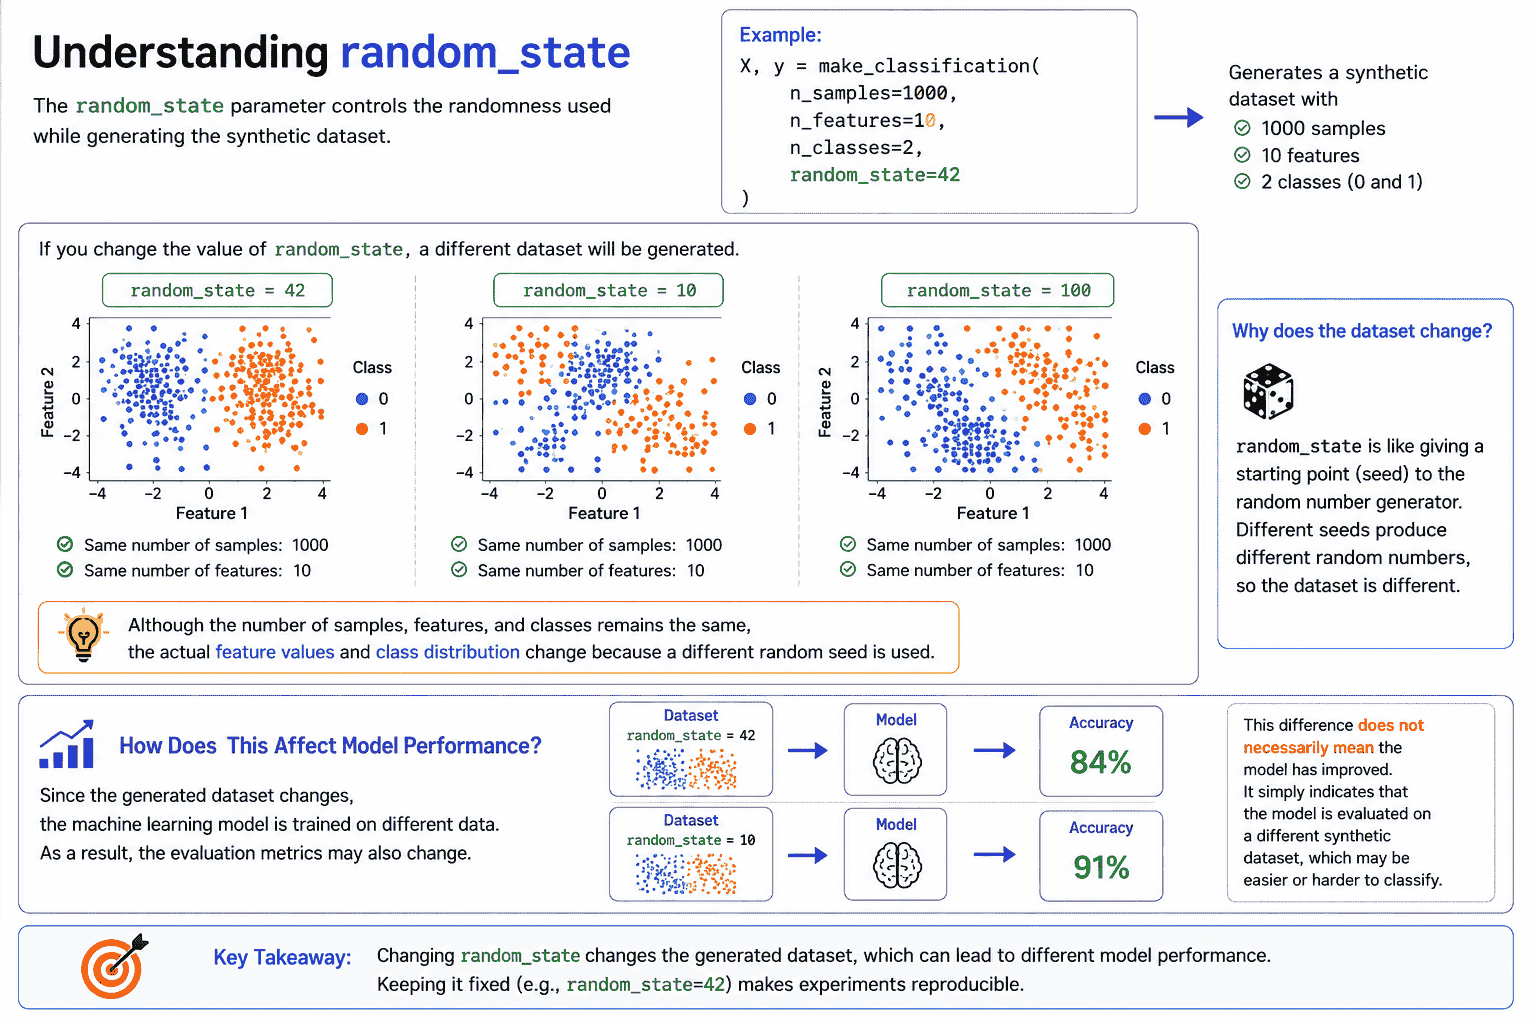



In [5]:
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (1000, 10)
Target Vector Shape: (1000,)


In [6]:
# Convert the feature matrix (X) into a Pandas DataFrame
# and assign meaningful column names (Feature_0, Feature_1, ..., Feature_9)
# for better readability and data analysis.
df = pd.DataFrame(
    X,
    columns=[f"Feature_{i}" for i in range(X.shape[1])]
)

# Display the first five rows of the dataset.
df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274
1,-0.916511,-0.566395,-1.008614,0.831617,-1.176962,1.820544,1.752375,-0.984534,0.363896,0.209470
2,-0.109484,-0.432774,-0.457649,0.793818,-0.268646,-1.836360,1.239086,-0.246383,-1.058145,-0.297376
3,1.750412,2.023606,1.688159,0.006800,-1.607661,0.184741,-2.619427,-0.357445,-1.473127,-0.190039
4,-0.224726,-0.711303,-0.220778,0.117124,1.536061,0.597538,0.348645,-0.939156,0.175915,0.236224


In [7]:
# Display the target variable (class labels) of the dataset.
y

array([0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

### **What Does Each Value Represent?**

Each value in `y` corresponds to the row at the same index in `X`.

For example:

| Sample (X) | Target (y) |
|------------|------------|
| X[0] | 0 |
| X[1] | 1 |
| X[2] | 0 |
| X[3] | 1 |

This means:
- `X[0]` belongs to **Class 0**
- `X[1]` belongs to **Class 1**
- and so on.

### Output

```python
array([0, 1, 0, 1, 1, 0, ...])
```

The output contains **1,000 labels**, one for each sample in the dataset.

## **Show class distribution**

In [8]:
pd.Series(y).value_counts()

,count
0,501
1,499


<Axes: >

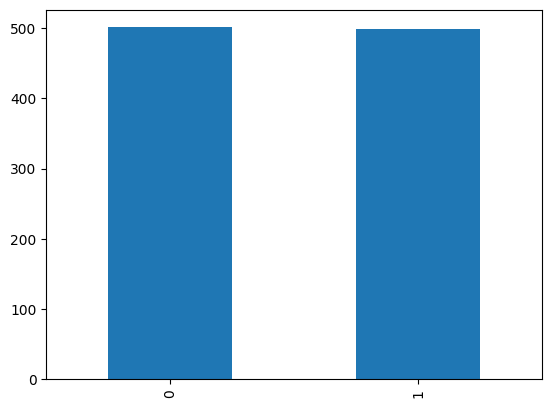

In [9]:
pd.Series(y).value_counts().plot(kind="bar")

In this notebook, the synthetic dataset generated by make_classification() has features on comparable scales. Therefore, the Logistic Regression model performs well even without feature scaling. For most real-world datasets, however, applying StandardScaler before training is recommended because Logistic Regression is sensitive to feature scales.

## **Splitting the Dataset into Training and Testing Sets**

In [9]:
# Import the train_test_split function to divide the dataset
# into training and testing sets.
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets.
# - 70% of the data is used to train the model.
# - 30% of the data is used to evaluate the model.
# - random_state=42 ensures the split is reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(700, 10)
(300, 10)
(700,)
(300,)


## **Training the Logistic Regression Model**

In [11]:
# Import the LogisticRegression class to build a logistic regression
# model for binary or multi-class classification.
from sklearn.linear_model import LogisticRegression

In [12]:
# Create an instance of the Logistic Regression model
# using the default hyperparameters.
logistic = LogisticRegression()

- The model has been created.
- No learning has taken place yet.
- The model does not know anything about the dataset.

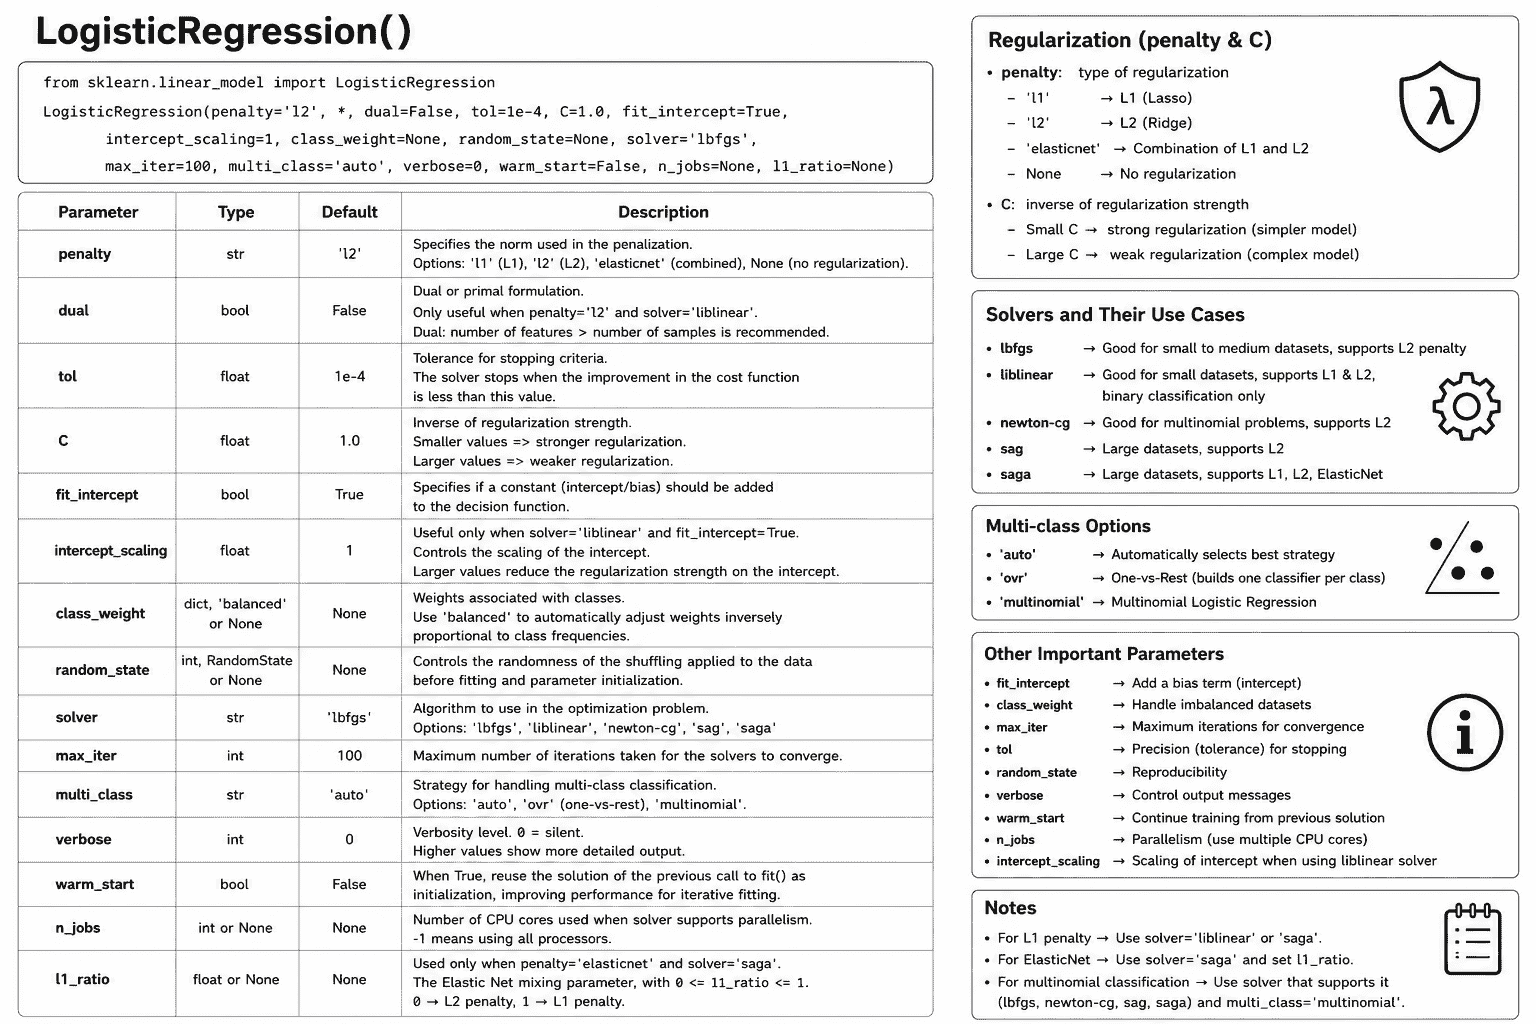



In [13]:
# Train the Logistic Regression model using the
# training features (X_train) and training target labels (y_train).
logistic.fit(X_train, y_train)

LogisticRegression()

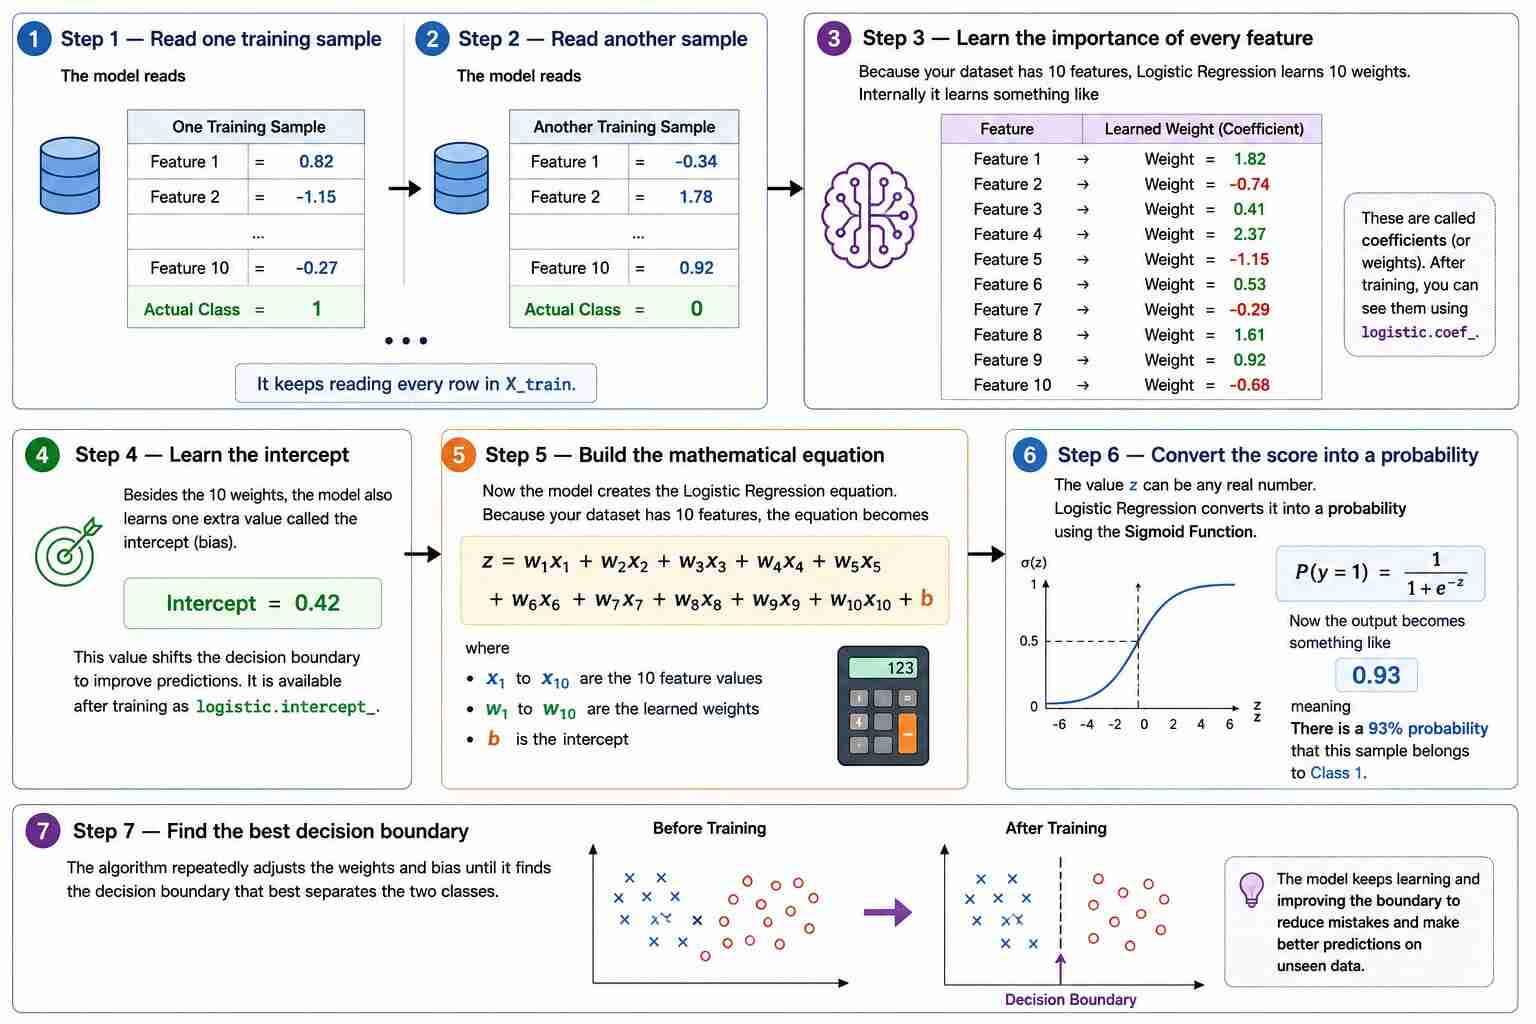

In [14]:
print("Intercept:")
print(logistic.intercept_)

print("\nCoefficients:")
print(logistic.coef_)

Intercept:
[0.09306387]

Coefficients:
[[-0.45063402  0.11231116 -0.74156534  0.08276314 -0.06901049 -0.28295706
   1.61185747 -0.00769261 -0.62367657  0.05969979]]


## **Making Predictions on the Test Dataset**

In [15]:
# Use the trained Logistic Regression model to predict
# the class labels for the test dataset.
y_pred = logistic.predict(X_test)

# Display the predicted class labels.
print(y_pred)

[0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 0 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 1
 1 1 1 0 1 1 0 0 0 1 1 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0
 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 1 1
 1 1 1 1 0 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 0 0 0 0 0 1 0
 0 0 1 0 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1
 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 1 0 1 1 0
 0 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 1 0 1 1 1 0 0 1 1 1 1
 0 1 0 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 0 1 1
 1 1 1 0]


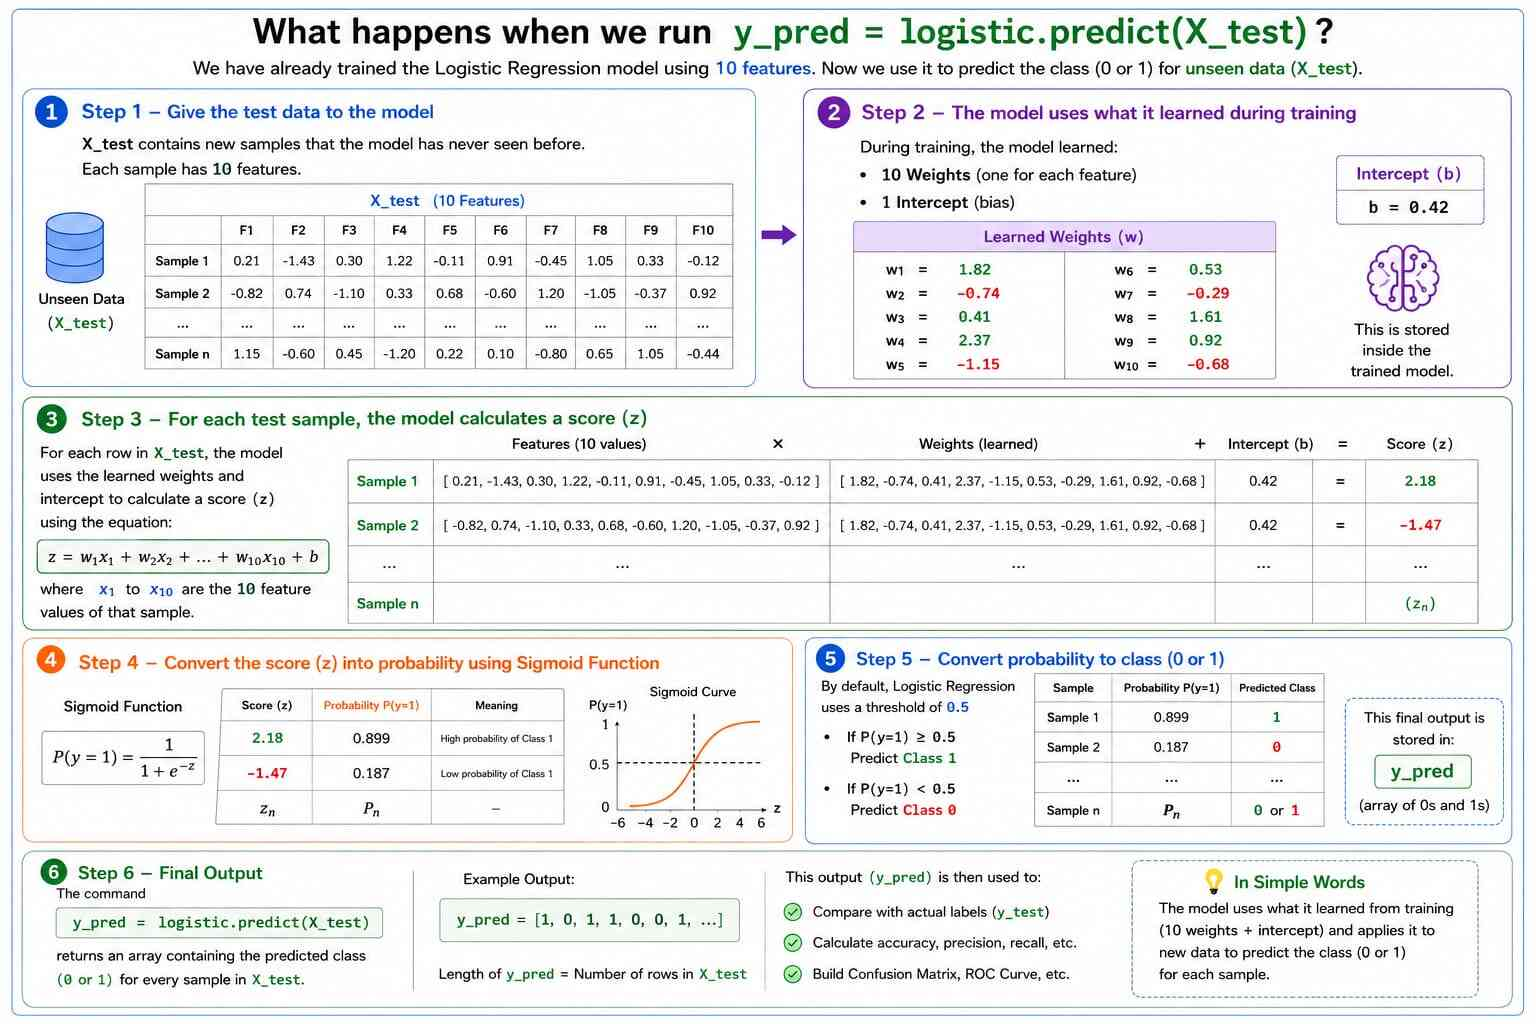

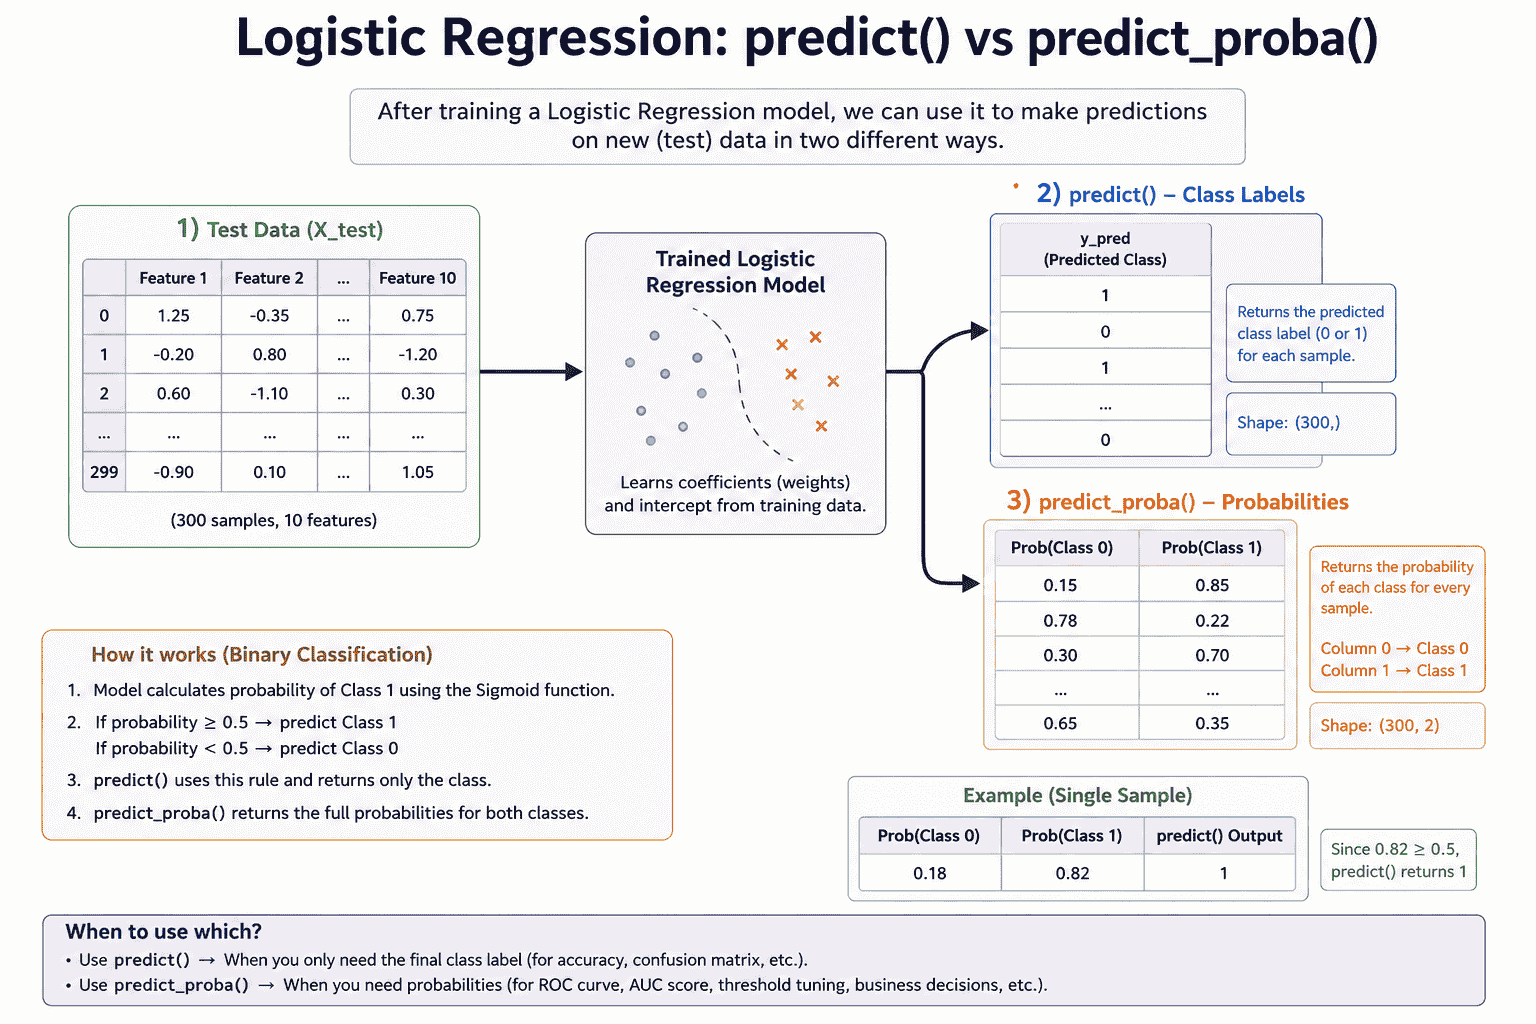



In [16]:
# Display the shape of the prediction array.
print(y_pred.shape)

(300,)


## **Predict Class Probabilities**

In [17]:
# Predict the probability for each class (Class 0 and Class 1)
y_pred_proba = logistic.predict_proba(X_test)

# Display the probabilities
y_pred_proba[:10]

array([[0.77447791, 0.22552209],
       [0.0336685 , 0.9663315 ],
       [0.67068215, 0.32931785],
       [0.0798668 , 0.9201332 ],
       [0.97661665, 0.02338335],
       [0.04135728, 0.95864272],
       [0.97902877, 0.02097123],
       [0.95936726, 0.04063274],
       [0.80852005, 0.19147995],
       [0.68495432, 0.31504568]])

In [18]:
# Display the shape of the probability array
print(y_pred_proba.shape)

(300, 2)


* Each row represents **one test sample**.
* There are **2 columns** because this is **binary classification**.

| Column   | Meaning                                            |
| -------- | -------------------------------------------------- |
| Column 0 | Probability that the sample belongs to **Class 0** |
| Column 1 | Probability that the sample belongs to **Class 1** |


In [19]:
# Create a DataFrame for better visualization
probability_df = pd.DataFrame(
    y_pred_proba,
    columns=["Probability of Class 0", "Probability of Class 1"]
)

probability_df.head(10)

,Probability of Class 0,Probability of Class 1
0,0.774478,0.225522
1,0.033668,0.966332
2,0.670682,0.329318
3,0.079867,0.920133
4,0.976617,0.023383
5,0.041357,0.958643
6,0.979029,0.020971
7,0.959367,0.040633
8,0.808520,0.191480
9,0.684954,0.315046


In [20]:
# Compare actual labels, predicted labels, and prediction probabilities
results = pd.DataFrame({
    "Actual Class": y_test,
    "Predicted Class": y_pred,
    "Probability of Class 0": y_pred_proba[:, 0],
    "Probability of Class 1": y_pred_proba[:, 1]
})

results.head(10)

,Actual Class,Predicted Class,Probability of Class 0,Probability of Class 1
0,0,0,0.774478,0.225522
1,1,1,0.033668,0.966332
2,1,0,0.670682,0.329318
3,1,1,0.079867,0.920133
4,0,0,0.976617,0.023383
5,1,1,0.041357,0.958643
6,0,0,0.979029,0.020971
7,0,0,0.959367,0.040633
8,0,0,0.808520,0.191480
9,0,0,0.684954,0.315046


## **Evaluating the Logistic Regression Model**

After generating predictions, the next step is to evaluate how well the Logistic Regression model performed on the test dataset.

The evaluation is performed using three commonly used classification metrics:

- **Accuracy Score**
- **Confusion Matrix**
- **Classification Report**


### **Understanding the Confusion Matrix (before we compute it)**

A **Confusion Matrix** compares actual vs predicted labels. For binary classification it has 4 outcomes:

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | True Negative (TN) — correctly predicted 0 | False Positive (FP) — predicted 1, actually 0 |
| **Actual 1** | False Negative (FN) — predicted 0, actually 1 | True Positive (TP) — correctly predicted 1 |

From these four numbers, all classification metrics are derived:
- **Accuracy** = (TP + TN) / Total — overall correctness
- **Precision** = TP / (TP + FP) — of everything predicted positive, how much was actually positive
- **Recall** = TP / (TP + FN) — of everything actually positive, how much did we catch
- **F1-score** = harmonic mean of Precision and Recall — balances both

Now let's compute these for our model:


In [21]:
# Import evaluation metrics to measure the performance
# of the classification model.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate the accuracy of the model.
score = accuracy_score(y_test, y_pred)
print("Accuracy Score:", score)

# Generate the confusion matrix.
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Display the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.8466666666666667

Confusion Matrix:
[[118  17]
 [ 29 136]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       135
           1       0.89      0.82      0.86       165

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



For each class:

* Precision tells us how reliable positive predictions are.
* Recall tells us how many actual positives were identified.
* F1-score balances precision and recall.
* Support indicates the number of actual samples belonging to that class.

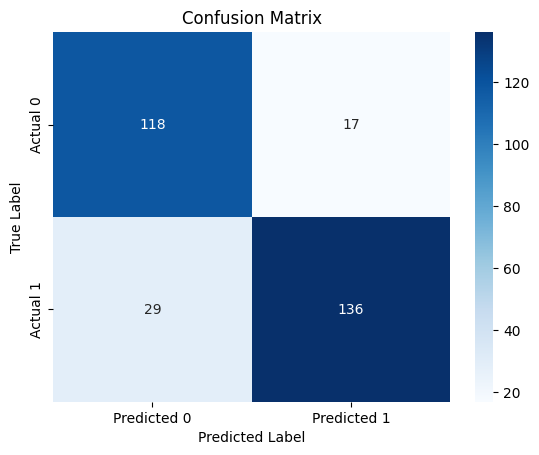

In [22]:
# Visualize the confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# **Hyperparameter Tuning And Cross validation**

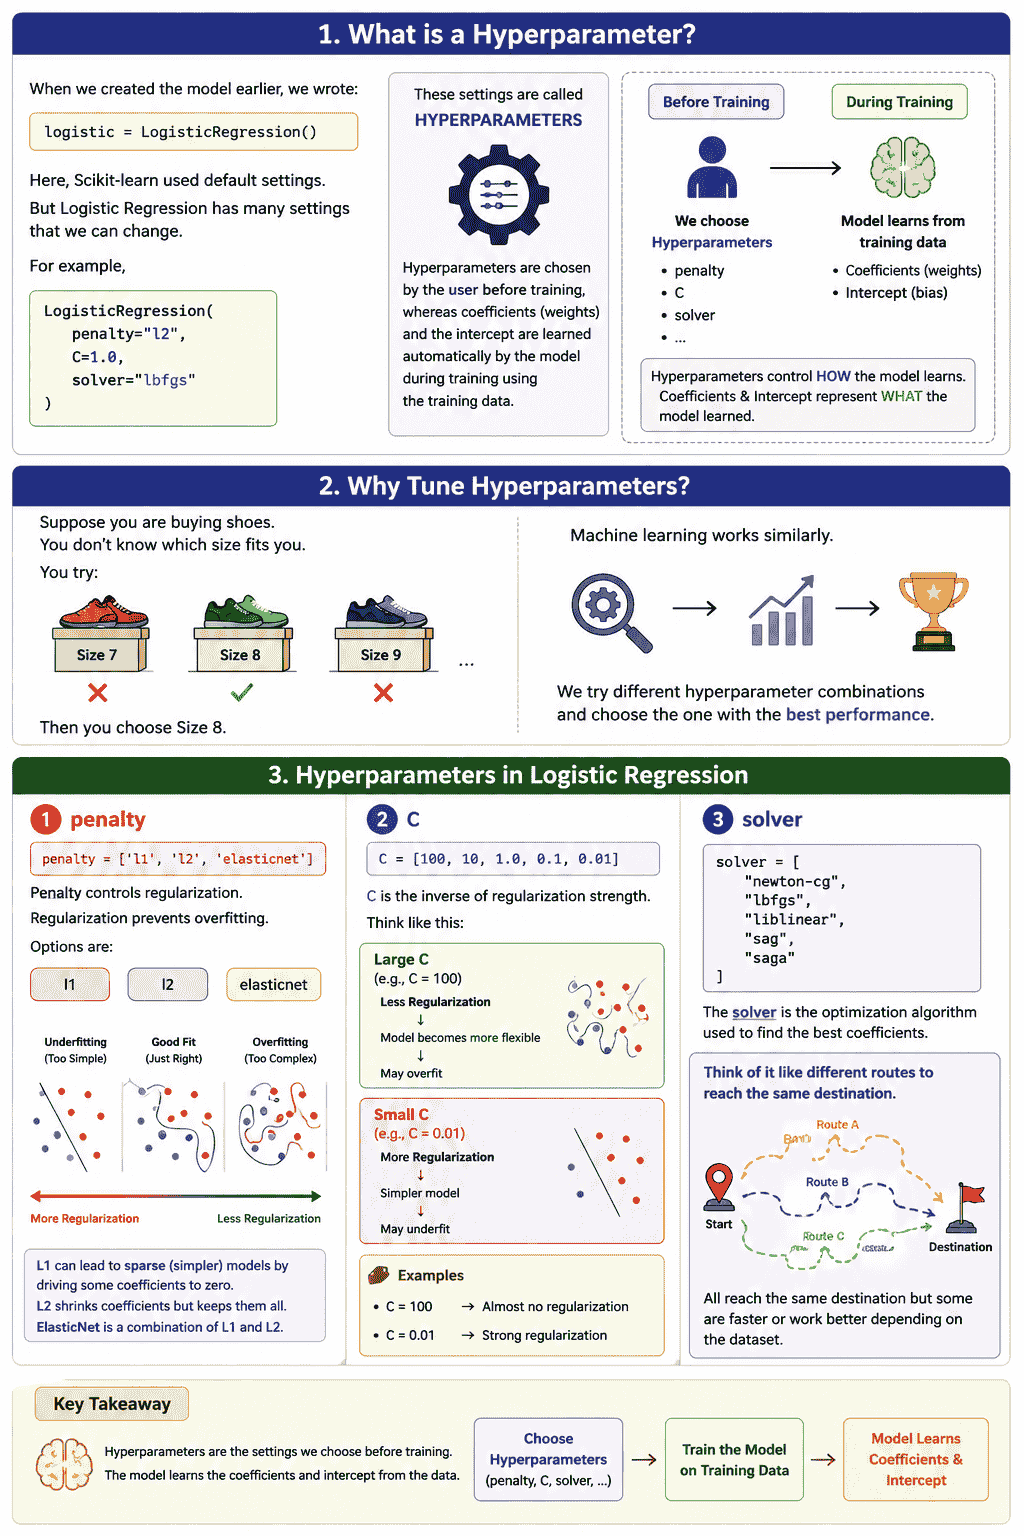



### **What Do These Hyperparameters Actually Mean?**

Before tuning, it helps to know what each hyperparameter controls:

- **`penalty`** — the type of **regularization** used to prevent overfitting by discouraging overly large coefficients.
  - `l1` (Lasso): can shrink some coefficients to exactly 0 — useful for feature selection.
  - `l2` (Ridge): shrinks coefficients smoothly but rarely to exactly 0. This is the default.
  - `elasticnet`: a mix of `l1` and `l2`.
- **`C`** — the **inverse of regularization strength**.
  - Small `C` (e.g. 0.01) → **stronger** regularization → simpler model, less overfitting risk.
  - Large `C` (e.g. 100) → **weaker** regularization → model fits training data more closely, higher overfitting risk.
- **`solver`** — the optimization algorithm used internally to find the best coefficients. Different solvers support different penalties (e.g. `liblinear` and `saga` support `l1`; most others only support `l2`).

`GridSearchCV` (next section) will try combinations of these automatically and tell us which combination works best — so you don't have to guess.


In [23]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression()

# Hyperparameters to tune
penalty = ['l1', 'l2', 'elasticnet']
C = [100, 10, 1.0, 0.1, 0.01]
solver = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']

In [24]:
# Store all hyperparameters in a dictionary
params = {
    'penalty': penalty,
    'C': C,
    'solver': solver
}

# **Hyperparameter Tuning using GridSearchCV**

Instead of manually trying different hyperparameter values, Scikit-learn provides the **GridSearchCV** class, which automatically tests multiple combinations of hyperparameters and selects the best-performing model.

GridSearchCV combines two important techniques:

- **Hyperparameter Tuning**
- **Cross Validation**

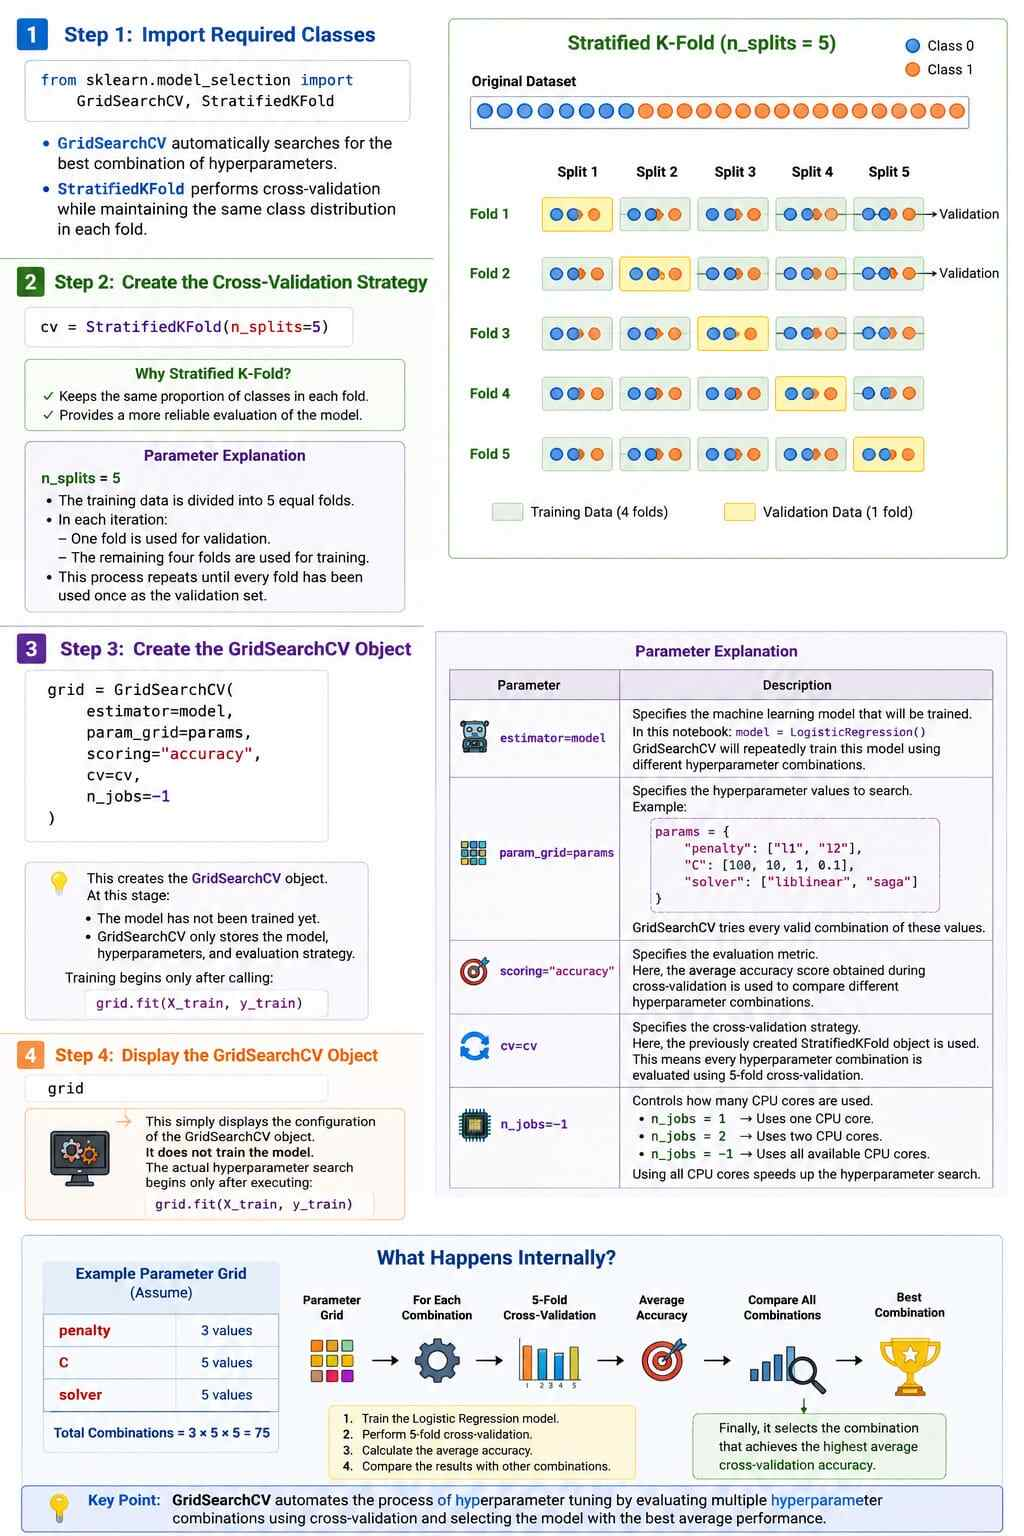



In [25]:
# Import GridSearchCV for hyperparameter tuning
# and StratifiedKFold for cross-validation.
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Create a Stratified K-Fold cross-validator with 5 folds.
cv = StratifiedKFold(n_splits=5)

# Create a GridSearchCV object.
grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

# Display the GridSearchCV object.
grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

# **Training and Evaluating the Tuned Logistic Regression Model**

After creating the `GridSearchCV` object, the next step is to train it using the training dataset.

Unlike the `LogisticRegression` model, `GridSearchCV` does much more than simply training a single model.

It automatically:

1. Tries multiple hyperparameter combinations.
2. Performs cross-validation for each combination.
3. Calculates the average evaluation score.
4. Selects the best-performing hyperparameter combination.
5. Retrains the model using the best hyperparameters on the entire training dataset.


> **Note:** GridSearchCV automates hyperparameter tuning by testing multiple hyperparameter combinations using cross-validation and returns the model with the best average validation performance. This tuned model is then used to make predictions on unseen test data.

**Note:** Not every `solver` supports every `penalty` (e.g. most solvers don't support `l1`). When `GridSearchCV` tries an invalid combination, scikit-learn prints a warning but simply skips that combination — it does not crash. We suppress these expected warnings below purely to keep the output clean; we are **not** hiding real errors.


In [26]:
import warnings
warnings.filterwarnings("ignore")

In [27]:
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

`grid.fit(X_train, y_train)` When this line is executed, GridSearchCV begins the hyperparameter search.

For every valid combination of hyperparameters:

- A Logistic Regression model is created.
- The model is trained using cross-validation.
- The average accuracy across all folds is calculated.

Finally, the best-performing model is stored internally.

### **Display the Best Hyperparameters**

In [28]:
# This returns the hyperparameter combination that achieved the highest average
# cross-validation accuracy.

grid.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'newton-cg'}

These values are considered the optimal settings for this dataset.

### **Display the Best Cross-Validation Score**

In [29]:
# This returns the highest average cross-validation accuracy obtained
# during the hyperparameter search.
grid.best_score_

np.float64(0.8785714285714287)

This means the best hyperparameter combination achieved the average validation accuracy printed above (see `grid.best_score_` output).

> **Note:** This score is calculated using only the training dataset during cross-validation. It is different from the final testing accuracy computed below.


## **Predict on the Test Dataset**

In [30]:
y_pred_grid = grid.predict(X_test)

After identifying the best hyperparameters, GridSearchCV automatically trains a final Logistic Regression model using those hyperparameters.

The trained model is then used to predict the class labels for the unseen test dataset.

## **Evaluate the Tuned Model**

In [31]:
# Calculate the accuracy of the tuned model.
accuracy = accuracy_score(y_test, y_pred_grid)
print("\nAccuracy Score:", accuracy)

# Generate the confusion matrix.
cm = confusion_matrix(y_test, y_pred_grid)
print("\nConfusion Matrix:")
print(cm)

# Display the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_grid))


Accuracy Score: 0.8533333333333334

Confusion Matrix:
[[124  11]
 [ 33 132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       135
           1       0.92      0.80      0.86       165

    accuracy                           0.85       300
   macro avg       0.86      0.86      0.85       300
weighted avg       0.86      0.85      0.85       300



## **Hyperparameter Tuning using RandomizedSearchCV**

`RandomizedSearchCV` is another technique for hyperparameter tuning.

Like `GridSearchCV`, it searches for the best combination of hyperparameters using cross-validation.

The main difference is **how the hyperparameter combinations are selected**.

---

## **GridSearchCV vs RandomizedSearchCV**

### GridSearchCV

GridSearchCV evaluates **every possible hyperparameter combination**.

For example:

| Penalty | C | Solver |
|----------|---|---------|
| l1 | 100 | saga |
| l1 | 10 | saga |
| l2 | 1 | lbfgs |
| l2 | 0.1 | saga |
| ... | ... | ... |

Every valid combination is tested.

This usually provides the optimal solution but can be computationally expensive for large parameter grids.

---

### RandomizedSearchCV

RandomizedSearchCV does **not** evaluate every combination.

Instead, it randomly selects a specified number of combinations and evaluates only those.

For example, if there are 100 possible combinations and:

```python
n_iter = 10
```

RandomizedSearchCV evaluates only **10 randomly selected combinations**.

This makes it significantly faster while often producing results similar to GridSearchCV.



| GridSearchCV | RandomizedSearchCV |
|---------------|--------------------|
| Evaluates every hyperparameter combination. | Evaluates only randomly selected combinations. |
| More computationally expensive. | Faster and more efficient for large search spaces. |
| More likely to find the optimal hyperparameters. | Often finds near-optimal hyperparameters with much less computation time. |
| Best suited for smaller parameter grids. | Best suited for larger parameter grids. |

> **Key Point:** RandomizedSearchCV is a faster alternative to GridSearchCV. Instead of evaluating every possible hyperparameter combination, it randomly samples a specified number of combinations, performs cross-validation, and selects the model with the best average validation performance.

In [32]:
from sklearn.model_selection import RandomizedSearchCV

In [33]:
# Define the hyperparameter search space for RandomizedSearchCV.
random_params = [
    {
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"],
        "C": [100, 10, 1.0, 0.1, 0.01]
    },
    {
        "penalty": ["l2"],
        "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"],
        "C": [100, 10, 1.0, 0.1, 0.01]
    },
    {
        "penalty": ["elasticnet"],
        "solver": ["saga"],
        "C": [100, 10, 1.0, 0.1, 0.01],
        "l1_ratio": [0.2, 0.5, 0.8]
    }
]

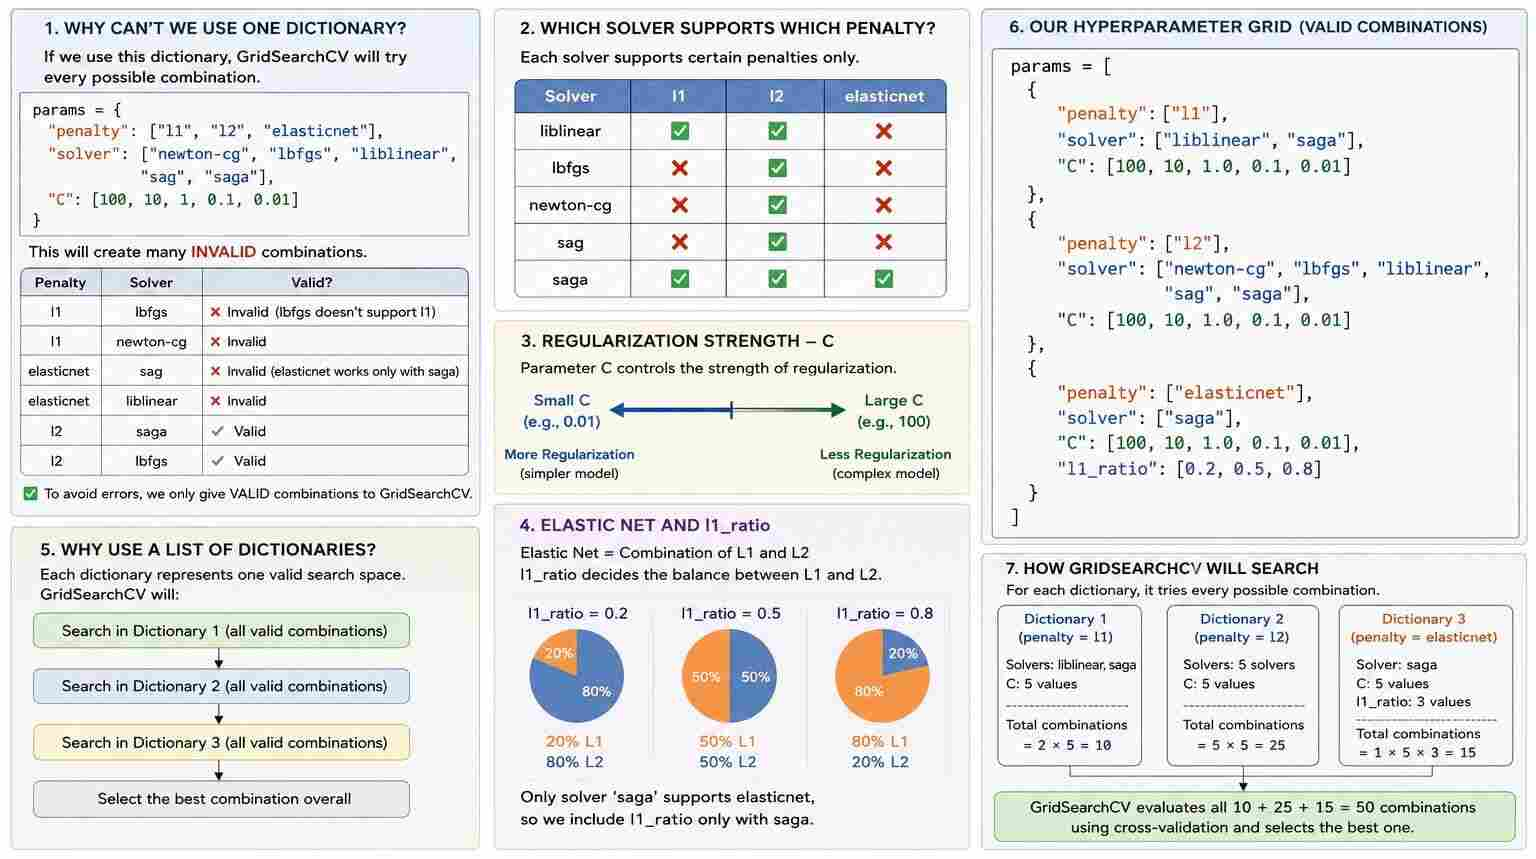



In [34]:
# Create the RandomizedSearchCV object.
random_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=random_params,
    scoring="accuracy",
    cv=cv,
    n_iter=10,
    random_state=42,
    n_jobs=-1
)

In [35]:
# Train the RandomizedSearchCV object.
random_cv.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=LogisticRegression(), n_jobs=-1,
                   param_distributions=[{'C': [100, 10, 1.0, 0.1, 0.01],
                                         'penalty': ['l1'],
                                         'solver': ['liblinear', 'saga']},
                                        {'C': [100, 10, 1.0, 0.1, 0.01],
                                         'penalty': ['l2'],
                                         'solver': ['newton-cg', 'lbfgs',
                                                    'liblinear', 'sag',
                                                    'saga']},
                                        {'C': [100, 10, 1.0, 0.1, 0.01],
                                         'l1_ratio': [0.2, 0.5, 0.8],
                                         'penalty': ['elasticnet'],
                                         'solver': ['saga']}],
                   random_state=42, scoring='accuracy')

In [36]:
# Display the best hyperparameters.
print("Best Hyperparameters:", random_cv.best_params_)

# Display the best cross-validation accuracy.
print("Best Cross-Validation Accuracy:", random_cv.best_score_)

Best Hyperparameters: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 0.01}
Best Cross-Validation Accuracy: 0.8785714285714287


## **Prediction and Evaluation**

In [37]:
# Predict the class labels for the test dataset.
y_pred_random_cv = random_cv.predict(X_test)

In [38]:
# Calculate the accuracy of the tuned model.
accuracy = accuracy_score(y_test, y_pred_random_cv)
print("Accuracy Score:", accuracy)

# Generate the confusion matrix.
cm = confusion_matrix(y_test, y_pred_random_cv)
print("\nConfusion Matrix:")
print(cm)

# Display the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_random_cv))

Accuracy Score: 0.8533333333333334

Confusion Matrix:
[[124  11]
 [ 33 132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       135
           1       0.92      0.80      0.86       165

    accuracy                           0.85       300
   macro avg       0.86      0.86      0.85       300
weighted avg       0.86      0.85      0.85       300



## **Comparing All Three Models**

Let's put the baseline model side-by-side with the two tuned versions to see whether tuning actually helped:

In [39]:
# Compare accuracy of the baseline model vs GridSearchCV vs RandomizedSearchCV
comparison = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "GridSearchCV (tuned)", "RandomizedSearchCV (tuned)"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_grid),
        accuracy_score(y_test, y_pred_random_cv),
    ]
})
comparison

,Model,Test Accuracy
0,Baseline Logistic Regression,0.846667
1,GridSearchCV (tuned),0.853333
2,RandomizedSearchCV (tuned),0.853333


## **Conclusion — What We Learned**

- Logistic Regression predicts **probabilities** using the **Sigmoid function**, then converts them into class labels using a 0.5 threshold.
- We trained a **baseline** model with default settings, then improved it using **GridSearchCV** (exhaustive search) and **RandomizedSearchCV** (random sampling of combinations).
- Model quality was evaluated with **Accuracy**, the **Confusion Matrix**, and **Precision/Recall/F1** — not accuracy alone, since accuracy can be misleading on imbalanced datasets.
- Hyperparameter tuning (`C`, `penalty`, `solver`) controls the **regularization** trade-off between underfitting and overfitting.




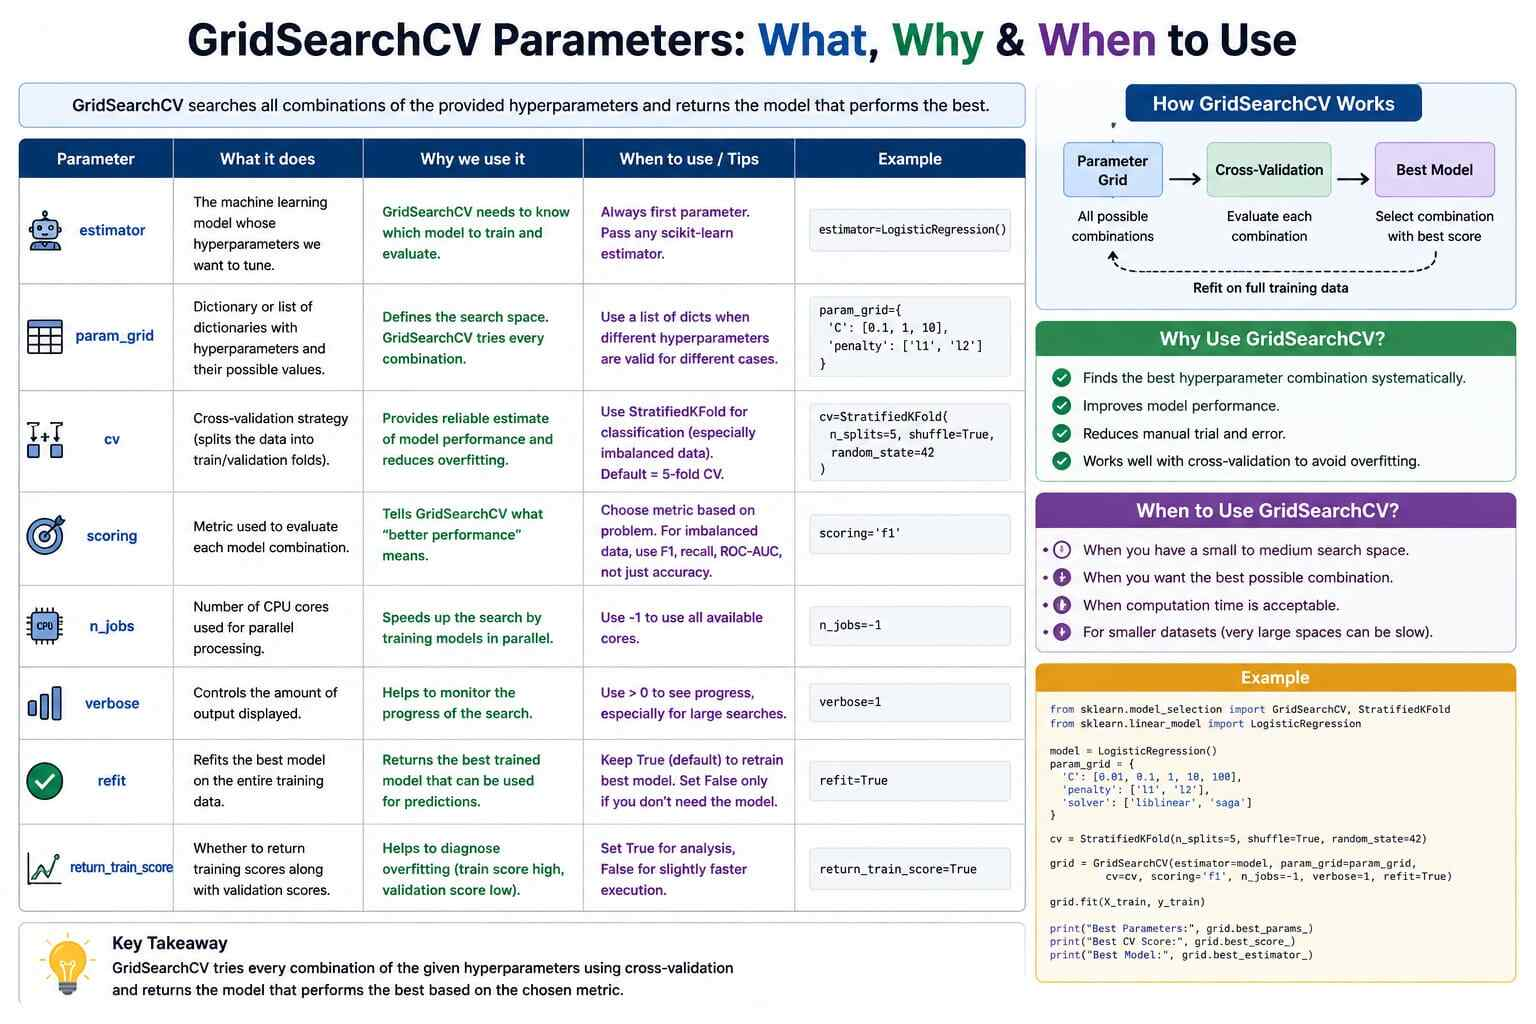

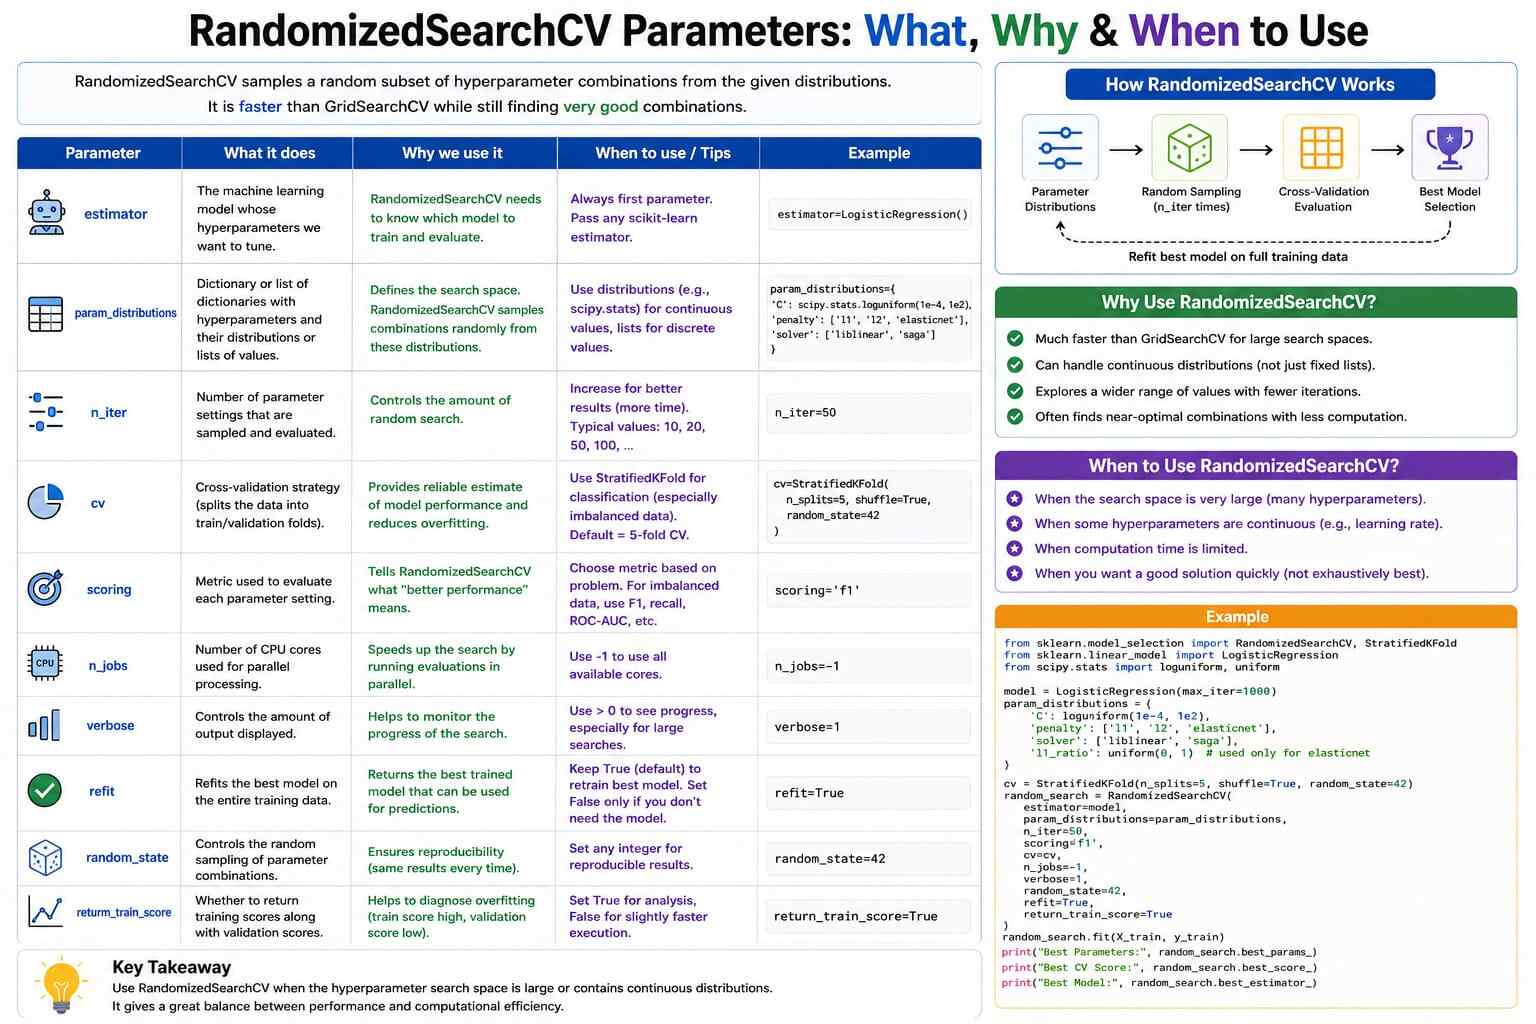